In [ ]:
# Obesity Prediction Analysis

#This project analyzes lifestyle factors and predicts obesity using machine learning models.

In [ ]:
#import套件
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.cluster import KMeans

In [26]:
#讀資料
#from google.colab import files
#uploaded = files.upload()
url= "https://raw.githubusercontent.com/alicey2k/obesity-project/main/obesity_project_dataset.xlsx"
df = pd.read_excel(url)
df.head()

,calorie_intake,sugar,fat,fiber,water_intake,exercise_freq,sleep_hours,sedentary_hours,fast_food_freq,group
0,1765.747759,88.516406,102.792544,16.198606,1.022264,2.324102,6.559097,5.739057,2.236624,Normal
1,2598.938179,40.295861,79.523929,14.206435,1.776752,3.914385,7.690327,6.843697,3.127064,Obese
2,2313.191399,66.630849,108.320024,16.774101,2.344940,4.760617,7.527221,4.133537,1.491902,Obese
3,1597.482114,50.693207,99.723133,19.282174,1.368801,4.307722,6.126217,8.892003,-1.142857,Normal
4,1968.559899,89.365006,59.575737,24.203269,1.098777,5.857085,5.933764,8.100864,2.231894,Normal


In [ ]:
#Feature 選擇
features = ['calorie_intake','sugar','fat','fiber',
            'water_intake','exercise_freq',
            'sleep_hours','sedentary_hours','fast_food_freq']

X = df[features]
y = df['group'].map({'Normal':0,'Obese':1})

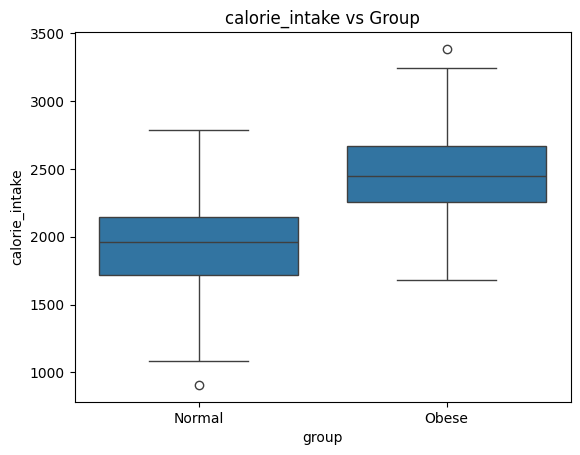

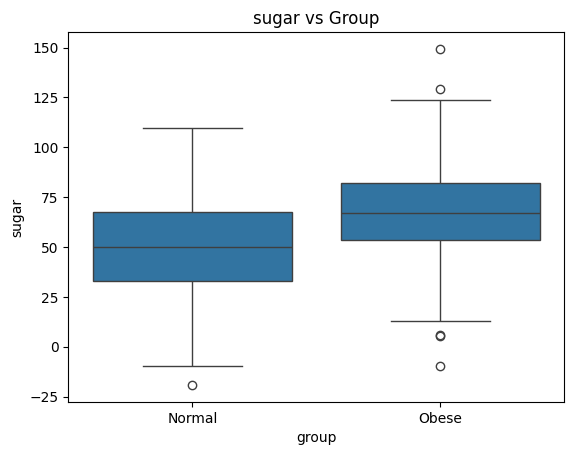

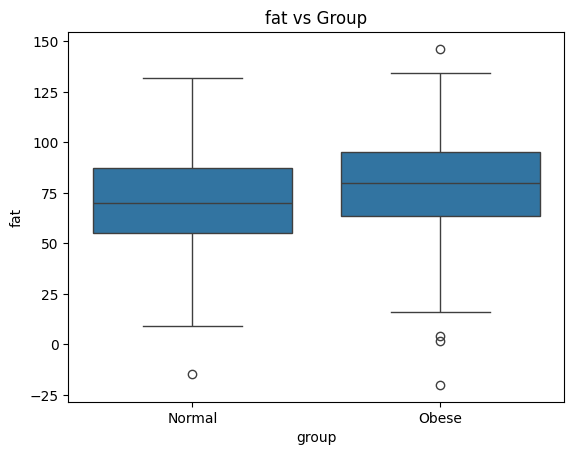

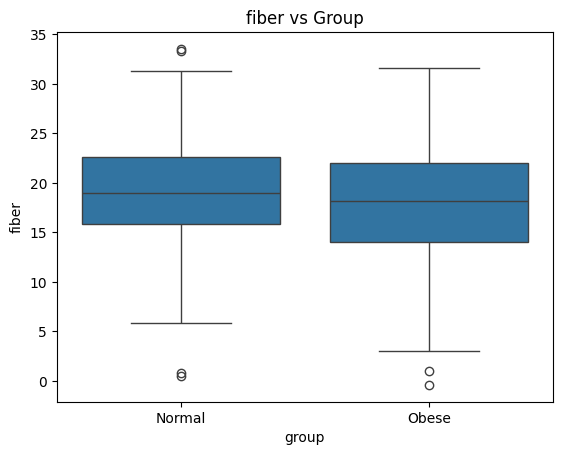

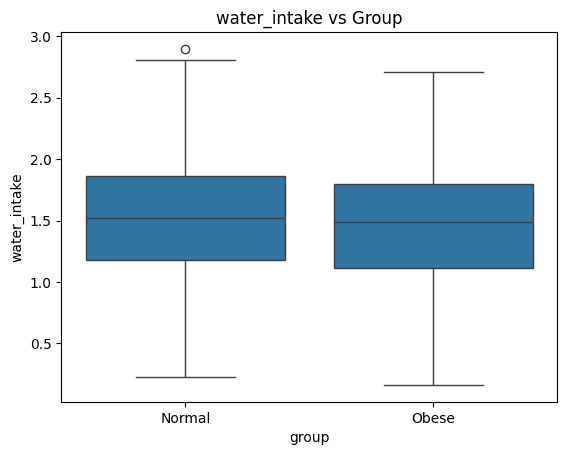

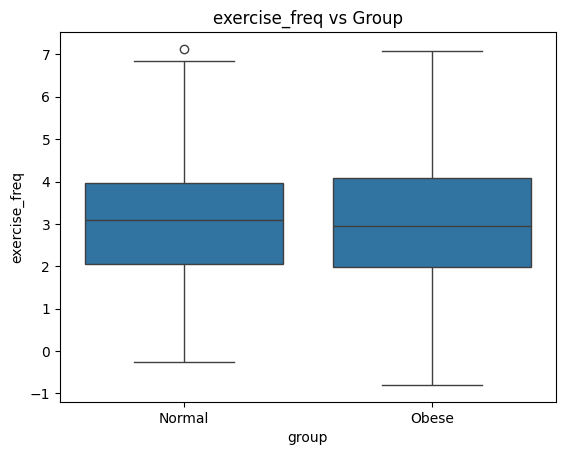

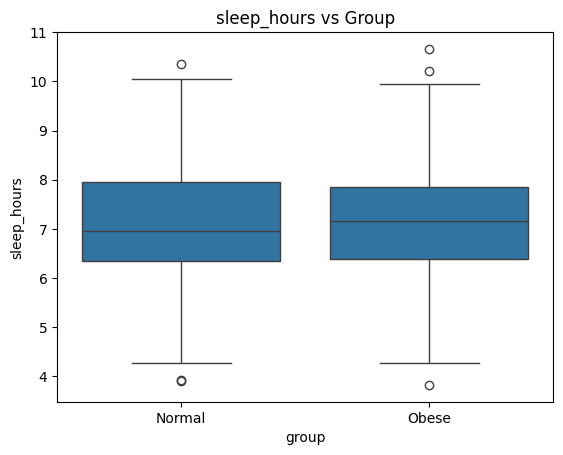

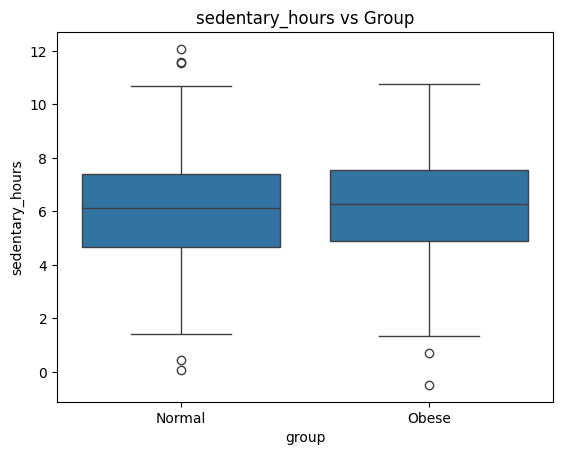

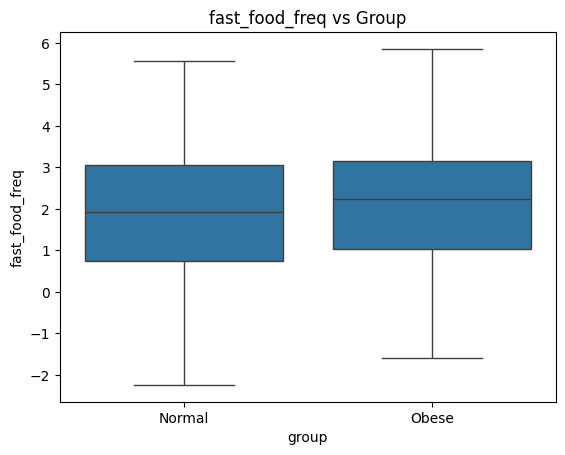

In [ ]:
#EDA：Boxplot
for col in features:
    plt.figure()
    sns.boxplot(x=df['group'], y=df[col])
    plt.title(f"{col} vs Group")
    plt.show()

In [ ]:
#T-test
for col in features:
    a = df[df['group']=='Normal'][col]
    b = df[df['group']=='Obese'][col]
    p = ttest_ind(a,b).pvalue
    print(col, "p =", round(p,6))

calorie_intake p = 0.0
sugar p = 0.0
fat p = 2e-06
fiber p = 0.009081
water_intake p = 0.117525
exercise_freq p = 0.435342
sleep_hours p = 0.675688
sedentary_hours p = 0.936125
fast_food_freq p = 0.106987


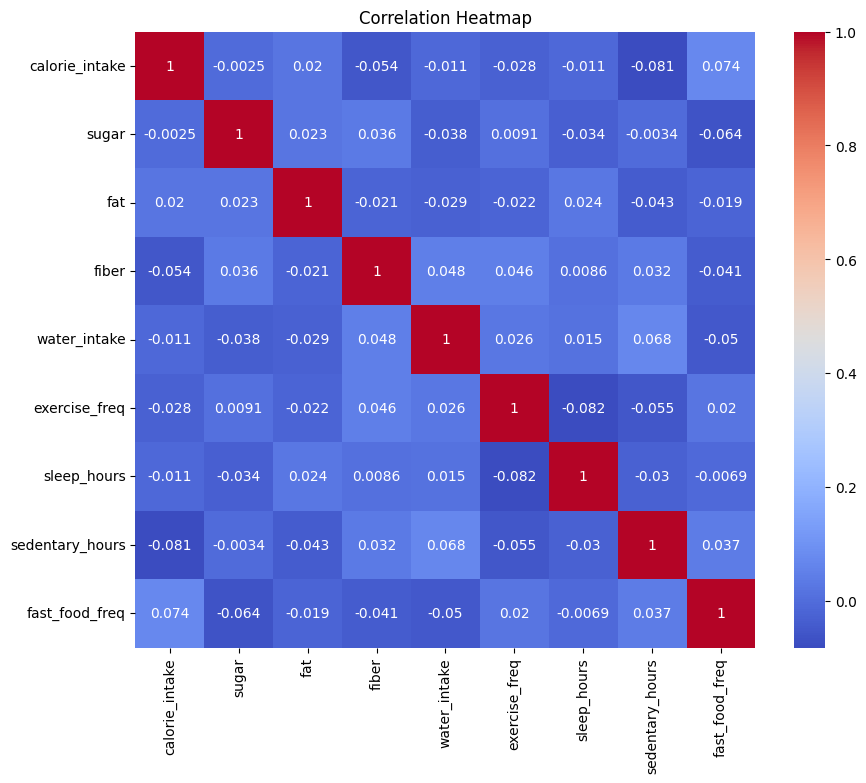

In [ ]:
#Heatmap（相關性）
plt.figure(figsize=(10,8))
corr = X.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

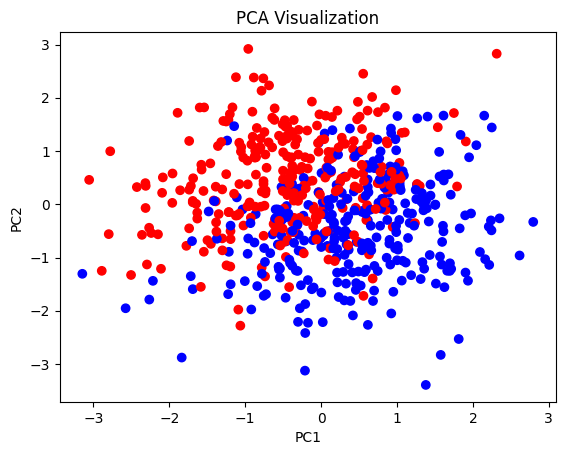

In [ ]:
#PCA視覺化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[['calorie_intake','sugar','fat','fiber']])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

colors = df['group'].map({'Normal':'blue','Obese':'red'})

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=colors)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

In [ ]:
#建立模型（Pipeline）
pipe_log = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', LogisticRegression())
])

pipe_rf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', RandomForestClassifier())
])

In [ ]:
#Cross Validation
scores_log = cross_val_score(pipe_log, X, y, cv=5)
scores_rf = cross_val_score(pipe_rf, X, y, cv=5)

print("Logistic:", scores_log.mean())
print("Random Forest:", scores_rf.mean())

Logistic: 0.8733333333333333
Random Forest: 0.8583333333333334


In [ ]:
#Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe_log.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

y_pred_log = pipe_log.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

In [ ]:
#Confusion Matrix（修正過）
cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Logistic:\n", cm_log)
print("Random Forest:\n", cm_rf)

Logistic:
 [[58  8]
 [ 7 47]]
Random Forest:
 [[56 10]
 [ 5 49]]


In [ ]:
#Accuracy
acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Logistic Accuracy:", acc_log)
print("Random Forest Accuracy:", acc_rf)

Logistic Accuracy: 0.875
Random Forest Accuracy: 0.875


In [ ]:
#Feature Importance
# Logistic
pipe_log.fit(X, y)
coef = pd.Series(pipe_log.named_steps['model'].coef_[0], index=X.columns)

# Random Forest
pipe_rf.fit(X, y)
importance = pd.Series(pipe_rf.named_steps['model'].feature_importances_, index=X.columns)

print("Logistic Coef:\n", coef)
print("\nRandom Forest Importance:\n", importance)

Logistic Coef:
 calorie_intake     8.478757
sugar              4.298443
fat                2.450565
fiber             -1.059987
water_intake      -0.512573
exercise_freq     -0.172464
sleep_hours        0.353539
sedentary_hours    0.740568
fast_food_freq     0.549708
dtype: float64

Random Forest Importance:
 calorie_intake     0.470492
sugar              0.156755
fat                0.084493
fiber              0.054848
water_intake       0.048840
exercise_freq      0.046263
sleep_hours        0.044894
sedentary_hours    0.044677
fast_food_freq     0.048738
dtype: float64


In [ ]:
#KMeans Clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df['cluster'] = labels

pd.crosstab(df['group'], df['cluster'], normalize='index')

cluster,0,1
group,,
Normal,0.34,0.66
Obese,0.68,0.32


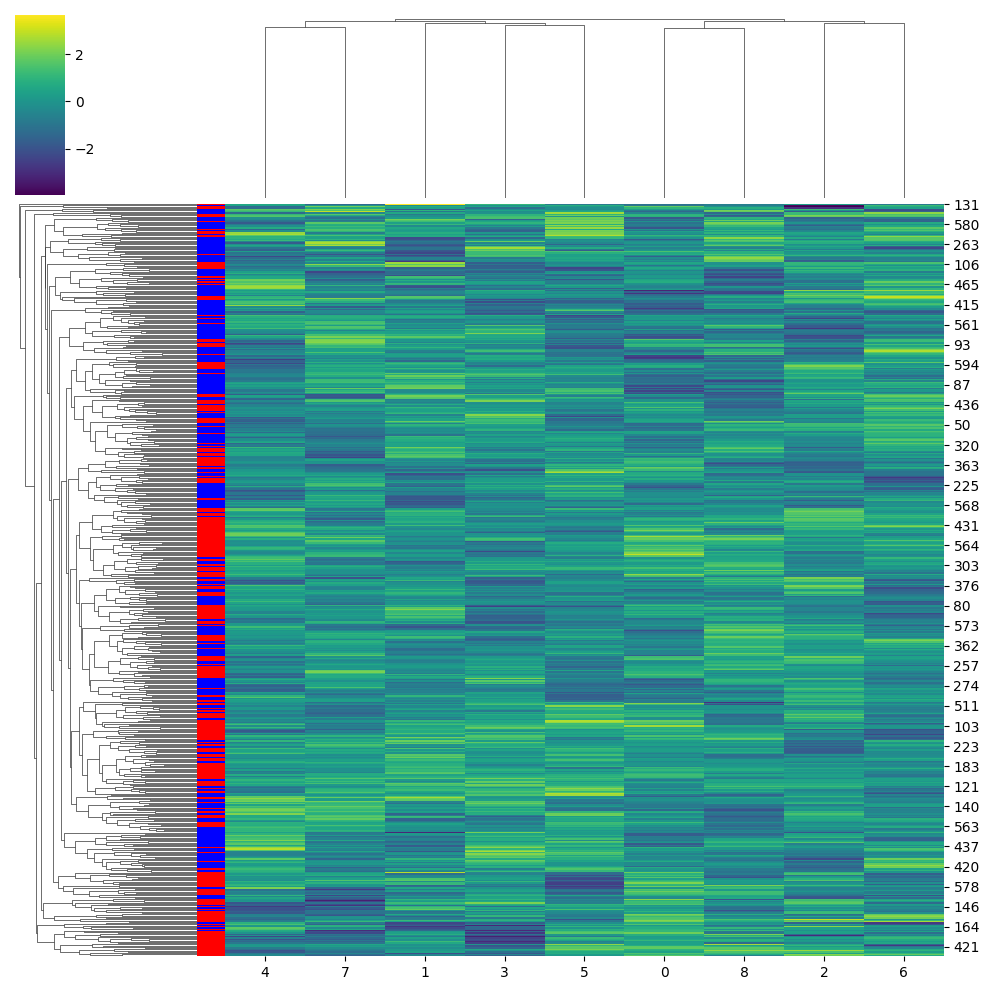

In [ ]:
#Clustermap
row_colors = df['group'].map({'Normal':'blue','Obese':'red'}).to_numpy()

sns.clustermap(X_scaled, cmap='viridis', row_colors=row_colors)
plt.show()